In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input

In [3]:
train_dir = r"C:\Users\Bonardo\anaconda3\envs\TEKOM_F1\Kuliah\IoTani\Chilli Plant Diseases Dataset\train"
test_dir = r"C:\Users\Bonardo\anaconda3\envs\TEKOM_F1\Kuliah\IoTani\Chilli Plant Diseases Dataset\test"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [5]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
training_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 4931 images belonging to 8 classes.


In [7]:
validation_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1232 images belonging to 8 classes.


In [8]:
# CNN
model = Sequential()

In [9]:
model.add(Input(shape=(224, 224, 3)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))

In [10]:
model.add(MaxPooling2D(pool_size=(2, 2)))

In [11]:
model.add(Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001)))

In [12]:
model.add(MaxPooling2D(pool_size=(2, 2)))

In [13]:
model.add(Flatten())

In [14]:
model.add(Dense(units=64, activation='relu'))

In [15]:
model.add(Dropout(0.5))

In [16]:
jumlah_kelas = training_set.num_classes

In [17]:
model.add(Dense(units=jumlah_kelas, activation='softmax'))

In [18]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 93312)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       5,972,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,982,696 (22.82 MB)

 Trainable params: 5,982,696 (22.82 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [21]:
history = model.fit(
    training_set,
    steps_per_epoch=len(training_set),
    epochs=50,
    validation_data=validation_set,
    validation_steps=len(validation_set),
    callbacks=[early_stop]
)

C:\Users\Bonardo\anaconda3\envs\TEKOM_F1\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 454s 3s/step - accuracy: 0.5182 - loss: 1.4961 - val_accuracy: 0.6282 - val_loss: 1.1352
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 392s 3s/step - accuracy: 0.6054 - loss: 1.1370 - val_accuracy: 0.6477 - val_loss: 1.0110
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.6404 - loss: 1.0144 - val_accuracy: 0.6550 - val_loss: 0.9919
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 393s 3s/step - accuracy: 0.6640 - loss: 0.9406 - val_accuracy: 0.6705 - val_loss: 0.8529
Epoch 5/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.6737 - loss: 0.8874 - val_accuracy: 0.7127 - val_loss: 0.7445
Epoch 6/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.6877 - loss: 0.8349 - val_accuracy: 0.7289 - val_loss: 0.6586
Epoch 7/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 460s 3s/step - accuracy: 0.6968 - loss: 0.7840 - val_accuracy: 0.7362 - val_loss: 0.6437
Epoch 8/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 714s 5s/step - accuracy: 0.7057 - loss: 0.7588 - val_accu

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [23]:
epochs_range = range(len(acc))

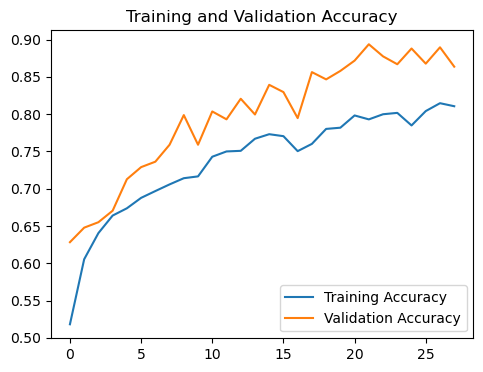

In [24]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

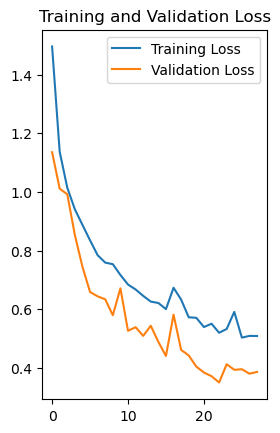

In [25]:
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()

In [208]:
# Untuk mengecek validasi gambar sesuai dengan data yang sudah dilatih
path_gambar = r'C:\Users\Bonardo\OneDrive\Dokumen\cabai1.jpg'

In [209]:
img = image.load_img(path_gambar, target_size=(224, 224))

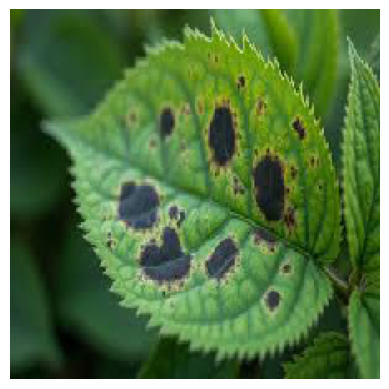

In [210]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [211]:
x = image.img_to_array(img)

In [212]:
x = x / 255.0

In [213]:
x = np.expand_dims(x, axis=0)

In [214]:
prediksi = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [215]:
index_kelas = np.argmax(prediksi)

In [216]:
labels = training_set.class_indices
labels = {v: k for k, v in labels.items()}
hasil_prediksi = labels[index_kelas]

In [217]:
print(f"Model memprediksi gambar ini sebagai: {hasil_prediksi}")
print(f"Confidence/Tingkat Keyakinan: {np.max(prediksi) * 100:.2f}%")

Model memprediksi gambar ini sebagai: Chilli __Whitefly
Confidence/Tingkat Keyakinan: 40.74%


In [57]:
model.save("model_cabai1.keras")
print("Model berhasil disimpan sebagai model_cabai.h5")

Model berhasil disimpan sebagai model_cabai.h5
